<a href="https://colab.research.google.com/github/gmxavier/FAT0413150/blob/main/notebooks/05.02-Chau-Ch5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This notebook shows how to use functions from `scipy`, `numpy`, `control` and `matplotlib` to substitute MATLAB functions used in [Chapter 5](https://ia802909.us.archive.org/32/items/process-control-a-first-course-with-matlab/Process%20Control%20A%20First%20Course%20with%20MATLAB.pdf#page=99) of Pao C. Chau, Process Control: A First Course with MATLAB.

In [ ]:
from sympy import symbols, Poly
from sympy.abc import s, t
from sympy.physics.control.lti import TransferFunction as TF, Series, Feedback
from sympy.physics.control import step_response_plot

In [ ]:
# Declaring symbols
Kc, Ka, Kp, Km, taup, tau1, tau2, tauI, tauD, A, alpha = symbols('K_c, K_a, K_p, K_m, tau_p, tau_1, tau_2, tau_I, tau_D, A, alpha')

# Defining a function to format TF as in textbooks
def tbformat(G):
  aux = Poly(Gsc.den, s).coeffs()
  aux1 = aux[-1]
  for k, kk in enumerate(aux):
    aux[k] = kk/aux1
  aux2 = Poly(Gsc.num, s).coeffs()
  for k, kk in enumerate(aux2):
    aux2[k] = kk/aux1
  return Poly(aux2,s)/Poly(aux,s)

In [ ]:
# Example 5.1, p. 96
Gc = TF(Kc,1,s)
Ga = TF(1,1,s)
Gp = TF(Kp,taup*s+1,s)
Gm = TF(1,1,s)
Gol = Series(Ga,Gc,Gp)
Gsc = Feedback(Gol,Gm)
Gsc = Series(Gsc,Gm)
Gsc = Gsc.doit().simplify()
tbformat(Gsc) #same as eq. E5.2

K_c*K_p/((K_c*K_p + 1)*(s*tau_p/(K_c*K_p + 1) + 1))

In [ ]:
# Example 5.2, p. 98
Gc = TF(Kc,1,s)
Ga = TF(1,1,s)
Gp = TF(Kp,(tau1*s+1)*(tau2*s+1),s)
Gm = TF(1,1,s)
Gol = Series(Ga,Gc,Gp)
Gsc = Feedback(Gol,Gm)
Gsc = Series(Gsc,Gm)
Gsc = Gsc.doit().simplify().expand()
tbformat(Gsc) #same as eq. E5.4

K_c*K_p/((K_c*K_p + 1)*(s**2*tau_1*tau_2/(K_c*K_p + 1) + s*(tau_1 + tau_2)/(K_c*K_p + 1) + 1))

In [ ]:
# Example 5.3, p. 99
Gc = TF(Kc*(tauI*s+1),tauI*s,s)
Ga = TF(1,1,s)
Gp = TF(Kp,taup*s+1,s)
Gm = TF(1,1,s)
Gol = Series(Ga,Gc,Gp)
Gsc = Feedback(Gol,Gm)
Gsc = Series(Gsc,Gm)
Gsc = Gsc.doit().simplify().expand()
tbformat(Gsc) #same as eq. E5.6a

(s*tau_I + 1)/(1 + s**2*tau_I*tau_p/(K_c*K_p) + s*(K_c*K_p*tau_I + tau_I)/(K_c*K_p))

In [ ]:
# Example 5.4, p. 99
Gc = TF(Kc*(tauD*s+1),1,s)
Ga = TF(1,1,s)
Gp = TF(Kp,taup*s+1,s)
Gm = TF(1,1,s)
Gol = Series(Ga,Gc,Gp)
Gsc = Feedback(Gol,Gm)
Gsc = Series(Gsc,Gm)
Gsc = Gsc.doit().simplify().expand()
tbformat(Gsc) #same as eq. E5.8a

(K_c*K_p*s*tau_D/(K_c*K_p + 1) + K_c*K_p/(K_c*K_p + 1))/(s*(K_c*K_p*tau_D + tau_p)/(K_c*K_p + 1) + 1)

In [ ]:
# Example 5.5, p. 100
Gc = TF(Kc,1,s)
Ga = TF(1,1,s)
Gp = TF(1,A*s,s)
Gm = TF(1,1,s)
Gol = Series(Ga,Gc,Gp)
Gsc = Feedback(Gol,Gm)
Gsc = Series(Gsc,Gm)
Gsc = Gsc.doit().simplify().expand()
tbformat(Gsc) #same as eq. E5.9

1/(A*s/K_c + 1)

In [ ]:
# Another example
Gc = TF(Kc*(1+(tauD*s+1)/(alpha*tauD*s+1)),1,s)
Ga = TF(Ka,1,s)
Gp = TF(Kp,taup*s+1,s)
Gm = TF(Km,1,s)
Gol = Series(Ga,Gc,Gp)
Gsc = Feedback(Gol,Gm)
Gsc = Series(Gsc,Gm)
Gsc = Gsc.doit().simplify().expand()
tbformat(Gsc)

(2*K_a*K_c*K_m*K_p/(2*K_a*K_c*K_m*K_p + 1) + s*(K_a*K_c*K_m*K_p*alpha*tau_D + K_a*K_c*K_m*K_p*tau_D)/(2*K_a*K_c*K_m*K_p + 1))/(alpha*s**2*tau_D*tau_p/(2*K_a*K_c*K_m*K_p + 1) + s*(K_a*K_c*K_m*K_p*alpha*tau_D + K_a*K_c*K_m*K_p*tau_D + alpha*tau_D + tau_p)/(2*K_a*K_c*K_m*K_p + 1) + 1)

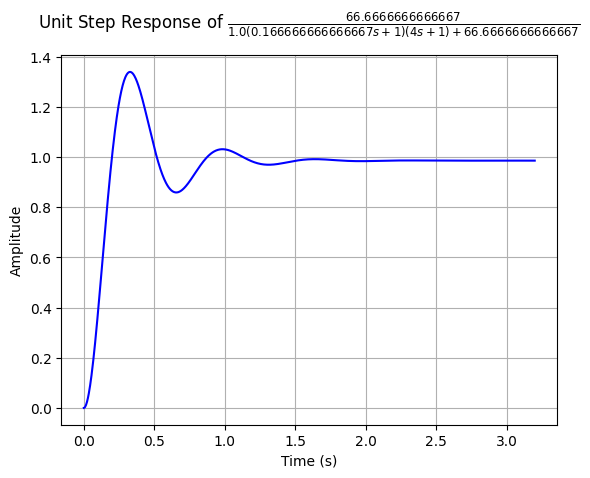

In [176]:
# Generic example with plot (distinct Km and Gm, add GL)
Km_ = TF(16/3,1,s)
Gc = TF(10000,1,s)
Ga = TF(-6/1600,(10/60)*s+1,s)
Gp = TF(-1/3,4*s+1,s)
Gm = TF(16/3,1,s)
GL = TF(1/4,4*s+1,s)
Gol = Series(Gc,Ga,Gp)
Gsc = Feedback(Gol,Gm)
Gsc = Series(Gsc,Km_)
Gsc = Gsc.doit().simplify()

# Extracting the parameters (gain, tau and zeta)
gain = float(Gsc.args[0])/float(Gsc.args[1].simplify().args[0].subs(s,1))
tau = (float(Gsc.args[1].simplify().args[2].subs(s,1))/float(Gsc.args[1].simplify().args[0].subs(s,1)))**0.5
twozetatau = float(Gsc.args[1].simplify().args[1].subs(s,1))/float(Gsc.args[1].simplify().args[0].subs(s,1))
zeta = twozetatau/2/tau

# Printing unit step response
step_response_plot(Gsc, upper_limit=10*tau/zeta)


In [172]:
tbformat(Gsc)

0.985221674876847/(0.00985221674876847*s**2 + 0.061576354679803*s + 1.0)

In [173]:
print(f'gain = {gain}', f'tau = {tau}', f'zeta = {zeta}')

gain = 0.9852216748768473 tau = 0.09925833339709303 zeta = 0.3101822918659158


In [174]:
import math
# Calculating transient response features (overshoot and decay ratio)
OS = math.e**(-math.pi*zeta/((1-zeta**2)**0.5))
DR = OS**2
print(f'OS = {OS}', f'DR = {DR}')

OS = 0.35878801777970915 DR = 0.12872884170229287
